# Phase 1b: Balanced Dataset - XL Training & Generation
## SVG Scaling Laws - CS-GY 6923 Optional Project

The Phase 2/3 dataset was ~93% font glyphs, producing single-stroke outputs.
This notebook trains an XL model on a rebalanced corpus (icons + emoji + fonts + stack)
and generates samples.

All outputs go to `*_balanced` directories. Phase 2/3 results are untouched.

Pipeline:
1. Download balanced corpus into `outputs/data/raw_balanced/`
2. Clean & normalize into `outputs/data/cleaned_balanced/`
3. Train tokenizer into `outputs/tokenizer_balanced/`
4. Prepare binary splits into `outputs/data/binary_balanced/`
5. Train XL for 4 epochs into `outputs/checkpoints/xl_balanced/`
6. Generate samples into `outputs/samples_balanced/`
7. Evaluate samples
8. Plot results

---
## Mount Google Drive
All outputs will be saved to Drive so they persist across Colab sessions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/ml-extra-credit-project'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Project dir: /content/drive/MyDrive/ml-extra-credit-project


---
## Clone / Pull Repository
Clone from GitHub or pull latest changes.

In [ ]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/ml-extra-credit-project'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git checkout balanced-rerun
print(f'Working directory: {os.getcwd()}')
!ls

Cloning repo ...
Cloning into '/content/ml-extra-credit-project'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 365 (delta 30), reused 35 (delta 17), pack-reused 296 (from 1)
Receiving objects: 100% (365/365), 2.95 MiB | 19.14 MiB/s, done.
Resolving deltas: 100% (225/225), done.
Branch 'balanced-rerun' set up to track remote branch 'balanced-rerun' from 'origin'.
Switched to a new branch 'balanced-rerun'
Working directory: /content/ml-extra-credit-project
configs		 notebooks	       README.md  requirements.txt  src
decision_log.md  PROJECT_BLUEPRINT.md  REPORT.md  scripts


---
## Install Dependencies

In [ ]:
!pip install -q -r requirements.txt

!apt-get install -q -y libcairo2-dev libpango1.0-dev libgdk-pixbuf2.0-dev libffi-dev shared-mime-info
!pip install -q cairosvg

print('All dependencies installed.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.2 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
libcairo2-dev is already the newest version (1.16.0-5ubuntu2).
libffi-dev is already the newest version (3.4.2-4).
libffi-dev set to manually installed.
shared-mime-info is already the newest version (2.1-2).
shared-mime-info set to manually installed.
The following additional packages will be installed:
  libdatrie-dev libfribidi-dev libgdk-pixbuf-2.0-dev libgdk-pixbuf-xlib-2.0-0
  libgdk-pixbuf-xlib-2.0-dev libgdk-pixbuf2.0-bin libgraphite2-dev
  libharfbuzz-dev libharfbuzz-gobject0 libharfbuzz-icu0 libthai-dev
  pango1.0-tools
Suggested packages:
  libdatrie-doc libgraphite2-utils libpango1.0-doc libthai-doc graphicsmagick
The following NEW packages will be installed:
  libdatrie-dev libfribidi-dev libgdk-pix

---
## Configure Output Paths
Symlink `outputs/` to Google Drive so everything persists. Balanced subdirs are created
alongside existing Phase 2/3 outputs — nothing is wiped.

In [ ]:
import os, shutil

REPO_DIR      = '/content/ml-extra-credit-project'
DRIVE_OUTPUTS = '/content/drive/MyDrive/ml-extra-credit-project/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.exists(LOCAL_OUTPUTS) and not os.path.islink(LOCAL_OUTPUTS):
    if os.listdir(LOCAL_OUTPUTS):
        print('Moving existing local outputs to Drive ...')
        shutil.copytree(LOCAL_OUTPUTS, DRIVE_OUTPUTS, dirs_exist_ok=True)
    shutil.rmtree(LOCAL_OUTPUTS)

if not os.path.islink(LOCAL_OUTPUTS):
    os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
    print(f'Created symlink: {LOCAL_OUTPUTS} → {DRIVE_OUTPUTS}')
else:
    print(f'Symlink already exists: {LOCAL_OUTPUTS} → {os.readlink(LOCAL_OUTPUTS)}')

for subdir in [
    'data/raw_balanced', 'data/cleaned_balanced', 'data/binary_balanced',
    'tokenizer_balanced', 'checkpoints/xl_balanced',
    'logs', 'samples_balanced', 'plots/balanced',
]:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, subdir), exist_ok=True)

print('Directory structure ready.')
!ls {DRIVE_OUTPUTS}

Created symlink: /content/ml-extra-credit-project/outputs → /content/drive/MyDrive/ml-extra-credit-project/outputs
Directory structure ready.
balanced_prompt_ids.json  data	 samples_balanced     tokenizer_balanced
checkpoints		  logs	 samples_balanced_v2
checkpoints_width_only	  plots  tokenizer


---
## Download Balanced Corpus

Downloads from HuggingFace into `outputs/data/raw_balanced/`. Existing Phase 2/3 raw data
in `outputs/data/raw/` is never touched.

| Source | Strategy | Expected size |
|---|---|---|
| `svg-icons-simple` | all | ~80K |
| `svg-emoji-simple` | all | ~4K |
| `svg-fonts-simple` | 20% subsample | ~200K |
| `svg-stack-simple` | ≤50K cap | ≤50K |

In [ ]:
import shutil, os

DRIVE_OUTPUTS = '/content/drive/MyDrive/ml-extra-credit-project/outputs'

dirs_to_wipe = [
    'data/raw_balanced',
    'data/cleaned_balanced',
    'data/binary_balanced',
    'tokenizer_balanced',
]

print('Wiping balanced intermediate outputs ...')
for d in dirs_to_wipe:
    full = os.path.join(DRIVE_OUTPUTS, d)
    if os.path.exists(full):
        shutil.rmtree(full)
        os.makedirs(full)
        print(f'  Cleared: {full}')
    else:
        os.makedirs(full, exist_ok=True)
        print(f'  Created: {full}')

print('\nReady for fresh balanced run.')

In [ ]:
!python scripts/01b_download_balanced.py --config configs/data_config_balanced.yaml

In [ ]:
import json
manifest = json.load(open('outputs/data/raw_balanced/download_manifest.json'))
print('Downloaded files:', manifest['downloaded_files'])
print(f'Estimated tokens (rough): {manifest["estimated_tokens_rough"]:,}')
print(f'Target tokens:            {manifest["target_tokens"]:,}')

---
## Clean & Normalize

Runs the same 9-step cleaning pipeline used in Phase 1, but writes to
`outputs/data/cleaned_balanced/`.

In [ ]:
!python scripts/02_clean_normalize.py --config configs/data_config_balanced.yaml

In [ ]:
import json
stats = json.load(open('outputs/data/dataset_stats_balanced.json'))
print('Cleaning statistics:')
print(f"  Total input SVGs:  {stats.get('total_input', '?'):>10,}")
print(f"  Total kept SVGs:   {stats.get('total_output', '?'):>10,}")
removed = stats.get('removed', {})
for reason, count in removed.items():
    print(f"  Removed ({reason:<18}): {count:>6,}")

import subprocess as sp
result = sp.run(['wc', '-l', 'outputs/data/cleaned_balanced/cleaned.jsonl'],
                capture_output=True, text=True)
print(f"\n  cleaned.jsonl lines: {result.stdout.strip()}")

### Append Multi-Element SVGs from svg-stack (non-simplified)

The StarVector "simplified" datasets converted all elements to single paths. To add structural diversity (circles, rectangles, groups), we source 100K multi-element SVGs from the non-simplified `starvector/svg-stack` dataset and append them to the cleaned corpus.

In [ ]:
import os
os.makedirs('outputs/data/raw_balanced', exist_ok=True)

from datasets import load_dataset
import json

ds = load_dataset("starvector/svg-stack", split="train", streaming=True)
count = 0
with open('outputs/data/raw_balanced/stack_multi.jsonl', 'w') as f:
    for ex in ds:
        svg = ex['Svg']
        if any(tag in svg for tag in ['<circle', '<rect', '<g ', '<ellipse', '<polygon', '<line']):
            if len(svg) < 5000:
                f.write(json.dumps({"svg": svg, "source": "stack-multi"}) + '\n')
                count += 1
                if count % 10000 == 0:
                    print(f"Collected {count}...")
                if count >= 100000:
                    break

print(f"Done: {count} multi-element SVGs")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Collected 10000...
Collected 20000...
Collected 30000...
Collected 40000...
Collected 50000...
Collected 60000...
Collected 70000...
Collected 80000...
Collected 90000...
Collected 100000...
Done: 100000 multi-element SVGs


In [ ]:
import json
import sys
sys.path.insert(0, '.')
from src.svg_utils import clean_svg, is_valid_xml

input_path = 'outputs/data/raw_balanced/stack_multi.jsonl'
output_path = 'outputs/data/cleaned_balanced/cleaned.jsonl'

kept = 0
skipped = 0
reasons = {}

with open(input_path) as f_in, open(output_path, 'a') as f_out:
    for line in f_in:
        obj = json.loads(line)
        svg = obj['svg']
        cleaned, reason = clean_svg(svg, decimal_places=1, min_length_chars=50)
        if cleaned and is_valid_xml(cleaned):
            f_out.write(json.dumps({"svg": cleaned, "source": "stack-multi"}) + '\n')
            kept += 1
        else:
            reasons[reason] = reasons.get(reason, 0) + 1
            skipped += 1

print(f"Multi-element SVGs: Kept {kept}, Skipped {skipped}")
print(f"Skip reasons: {reasons}")

# Verify total corpus size
total = sum(1 for _ in open(output_path))
print(f"Total cleaned corpus: {total} SVGs")

Multi-element SVGs: Kept 98832, Skipped 1168
Skip reasons: {'invalid_xml': 1168}
Total cleaned corpus: 814973 SVGs


In [ ]:
!python scripts/03_train_tokenizer.py --config configs/data_config_balanced.yaml

Loading cleaned SVGs: 814973it [00:09, 86071.99it/s]
Loaded 814,973 cleaned SVGs
Sampled 150,000 SVGs for tokenizer training (seed=42)

Training BPE tokenizer (vocab_size=4096) ...
Writing 150,000 SVGs to temp file for tokenizer training ...
Temp file: /content/tmpygw03dwi.txt  (231.6 MB)
Training tokenizer from file ...
[00:00:33] Tokenize words                 ██████████████████ 1016693  /  1016693
[00:00:09] Count pairs                    ██████████████████ 1016693  /  1016693
[00:02:30] Compute merges                 ██████████████████ 3836     /     3836
Temp file deleted.
Tokenizer saved to /tmp/tokenizer_local/tokenizer.json
  Verified: 293.7 KB, valid JSON
Actual vocabulary size: 4,096

--- Example tokenizations ---

Example 1 (900 chars → 125 tokens):
  SVG (first 120 chars): '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black'
  Token ids (first 20):  [1, 467, 954, 553, 380, 1877, 376, 1462, 390, 921, 525, 

In [ ]:
import numpy as np, json

with open('outputs/data/binary_balanced/split_info.json') as f:
    split_info = json.load(f)

train_tokens = split_info.get('train_tokens', split_info.get('train_size', 0))
val_tokens = split_info.get('val_tokens', split_info.get('val_size', 0))
test_tokens = split_info.get('test_tokens', split_info.get('test_size', 0))

print(f"Train tokens: {train_tokens:,}")
print(f"Val tokens:   {val_tokens:,}")
print(f"Test tokens:  {test_tokens:,}")
print(f"Total:        {train_tokens + val_tokens + test_tokens:,}")

assert train_tokens >= 100_000_000, f"BELOW 100M TARGET: {train_tokens}"
print(f"\n✓ Training tokens above 100M target")

Train tokens: 122,236,593
Val tokens:   1,249,413
Test tokens:  1,258,195
Total:        124,744,201

✓ Training tokens above 100M target


---
## Train BPE Tokenizer

Trains a new 4096-vocab BPE tokenizer on the balanced corpus and saves it to
`outputs/tokenizer_balanced/`. The original tokenizer in `outputs/tokenizer/` is untouched.

In [ ]:
!python scripts/03_train_tokenizer.py --config configs/data_config_balanced.yaml

Loading cleaned SVGs: 814973it [00:13, 60967.62it/s]
Loaded 814,973 cleaned SVGs
Sampled 150,000 SVGs for tokenizer training (seed=42)

Training BPE tokenizer (vocab_size=4096) ...
Writing 150,000 SVGs to temp file for tokenizer training ...
Temp file: /content/tmpmwjda7lb.txt  (231.6 MB)
Training tokenizer from file ...
[00:00:33] Tokenize words                 ██████████████████ 1016693  /  1016693
[00:00:09] Count pairs                    ██████████████████ 1016693  /  1016693
[00:02:26] Compute merges                 ██████████████████ 3836     /     3836
Temp file deleted.
Tokenizer saved to /tmp/tokenizer_local/tokenizer.json
  Verified: 293.7 KB, valid JSON
Actual vocabulary size: 4,096

--- Example tokenizations ---

Example 1 (900 chars → 125 tokens):
  SVG (first 120 chars): '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black'
  Token ids (first 20):  [1, 467, 954, 553, 380, 1877, 376, 1462, 390, 921, 525, 

In [ ]:
from src.tokenizer_utils import load_tokenizer
tok = load_tokenizer('outputs/tokenizer_balanced')

for tag in ['<circle', '<rect', '<g ', '<ellipse', 'fill="#']:
    enc = tok.encode(tag)
    print(f"  '{tag}' -> IDs: {enc.ids}, tokens: {[tok.id_to_token(i) for i in enc.ids]}")

  '<circle' -> IDs: [1, 31, 1345, 2], tokens: ['<BOS>', '<', 'circle', '<EOS>']
  '<rect' -> IDs: [1, 31, 963, 2], tokens: ['<BOS>', '<', 'rect', '<EOS>']
  '<g ' -> IDs: [1, 2764, 2], tokens: ['<BOS>', '<gĠ', '<EOS>']
  '<ellipse' -> IDs: [1, 31, 2519, 2], tokens: ['<BOS>', '<', 'ellipse', '<EOS>']
  'fill="#' -> IDs: [1, 765, 2], tokens: ['<BOS>', 'fill="#', '<EOS>']


---
## Prepare Binary Splits

Tokenizes all cleaned SVGs, applies the 1024-token length filter, splits 98/1/1, and
writes `train.bin`, `val.bin`, `test.bin` as numpy uint16 memmap files into
`outputs/data/binary_balanced/`.

In [ ]:
!python scripts/04_prepare_dataset.py --config configs/data_config_balanced.yaml

Loading tokenizer ...
  Vocab size: 4,096
Loading cleaned SVGs: 814973it [00:08, 95784.80it/s]

Total SVGs loaded: 814,973

Tokenizing and filtering (max_token_length=1024) ...
Tokenizing SVGs: 100% 814973/814973 [07:59<00:00, 1698.67it/s]
  Tokenized:  797,761
  Filtered (too long): 17,212 (2.1%)

Splitting train/val/test by file ...
  Train SVGs: 781,807
  Val SVGs:   7,977
  Test SVGs:  7,977

Writing binary files to local disk (/tmp/binary_local) ...
  train.bin: 155,444,730 tokens  (310.9 MB)
  val.bin:   1,587,716 tokens  (3.2 MB)
  test.bin:  1,597,098 tokens  (3.2 MB)

Verifying binary files ...
  All files verified OK.

Copying binary files to Drive (/content/ml-extra-credit-project/outputs/data/binary_balanced) ...
  test.bin  (3.2 MB) → /content/ml-extra-credit-project/outputs/data/binary_balanced/test.bin
  val.bin  (3.2 MB) → /content/ml-extra-credit-project/outputs/data/binary_balanced/val.bin
  train.bin  (310.9 MB) → /content/ml-extra-credit-project/outputs/data/binary_

In [ ]:
import numpy as np, json

with open('outputs/data/binary_balanced/split_info.json') as f:
    split_info = json.load(f)
print('Split information:')
print(json.dumps(split_info, indent=2))

print('\nVerifying binary files ...')
for split in ['train', 'val', 'test']:
    arr = np.memmap(f'outputs/data/binary_balanced/{split}.bin', dtype=np.uint16, mode='r')
    size_mb = arr.nbytes / 1e6
    print(f'  {split:5s}.bin: {len(arr):>12,} tokens  {size_mb:>8.1f} MB')

TARGET = 100_000_000
train_tokens = split_info['train_tokens']
check = 'ABOVE TARGET' if train_tokens >= TARGET else 'BELOW TARGET'
print(f'\nTraining tokens: {train_tokens:,}  ({check};  target: {TARGET:,})')

Split information:
{
  "train_svgs": 781807,
  "val_svgs": 7977,
  "test_svgs": 7977,
  "train_tokens": 155444730,
  "val_tokens": 1587716,
  "test_tokens": 1597098,
  "total_tokens": 158629544,
  "max_token_length": 1024,
  "n_filtered_too_long": 17212,
  "vocab_size": 4096,
  "dtype": "uint16",
  "bos_id": 1,
  "eos_id": 2,
  "seed": 42
}

Verifying binary files ...
  train.bin:  155,444,730 tokens     310.9 MB
  val  .bin:    1,587,716 tokens       3.2 MB
  test .bin:    1,597,098 tokens       3.2 MB

Training tokens: 155,444,730  (ABOVE TARGET;  target: 100,000,000)


---
## Train XL for 4 Epochs on Balanced Data

Same XL architecture (d_model=768, 12 layers, 12 heads) and hyperparameters as Phase 2.
Results write to `outputs/logs/result_xl_balanced.json` so the original
`result_xl.json` is untouched.

- `--ckpt_dir outputs/checkpoints/xl_balanced` — isolated checkpoint path
- `--result_suffix _balanced` — isolated result file
- `--data_config configs/data_config_balanced.yaml` — reads from `binary_balanced/`

In [ ]:
!python scripts/05_train_model.py \
    --model_name xl \
    --lr 3e-4 \
    --grad_accum 2 \
    --epochs 4 \
    --ckpt_dir outputs/checkpoints/xl_balanced \
    --result_suffix _balanced \
    --data_config configs/data_config_balanced.yaml \
    --resume

Device: cuda
Compiling model with torch.compile ...
Model: xl  |  Non-emb params: 85,056,000
Train tokens: 155,444,730  |  steps/epoch: 2,371  |  epochs: 4  |  total steps: 9,484
Will resume from: /tmp/checkpoints_local/xl/step_0000000.pt

Training: XL
  Non-emb params:  85,056,000
  Peak LR:         3.00e-04
  Batch size:      32 seqs/step × 2 accum = 64 seqs effective
  Tokens/step:     65,536  (seq_len=1024)
  Epochs:          4
  Steps/epoch:     2,371
  Total steps:     9,484
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/xl/
  Drive ckpts:     /content/ml-extra-credit-project/outputs/checkpoints/xl_balanced/xl/
  Log:             /content/ml-extra-credit-project/outputs/logs/training_xl.csv
Resuming from /tmp/checkpoints_local/xl/step_0000000.pt ...
  Resumed at step 1, best_val_loss=8.4732

Training xl for 9484 steps (bf16=True, grad_accum=2)
step     50 | train 6.7608 | lr 7.50e-05 | tok 3.3M | t 0.4min
step    100 | train 6.2960 | lr 1.50e-04 | tok 6.6M | t 

---
## Generate Samples

Generates unconditional samples from the balanced XL checkpoint. Outputs go to
`outputs/samples_balanced/`. The generation script uses `outputs/balanced_prompt_ids.json`
to determine the correct unconditional prompt token IDs for this tokenizer.

In [ ]:
!rm -rf outputs/samples_balanced_v2

!python scripts/10_generate_samples.py \
    --checkpoint outputs/checkpoints/xl_balanced/xl/best.pt \
    --tokenizer_dir outputs/tokenizer_balanced \
    --out_dir outputs/samples_balanced_v2 \
    --prompt_ids_override 1,467 \
    --n_uncond 50


Using prompt_ids_override: [1, 467]
Device: cuda
Loaded checkpoint: /content/ml-extra-credit-project/outputs/checkpoints/xl_balanced/xl/best.pt
  Non-emb params: 85,056,000
  Step:           7800
  Best val loss:  1.8630

=== Unconditional generation (16 per temperature) ===
  [1/48] t=0.5  tokens= 272  uncond_t0.5_00.svg
  [2/48] t=0.5  tokens=1026  uncond_t0.5_01.svg
  [3/48] t=0.5  tokens=1026  uncond_t0.5_02.svg
  [4/48] t=0.5  tokens= 292  uncond_t0.5_03.svg
  [5/48] t=0.5  tokens= 390  uncond_t0.5_04.svg
  [6/48] t=0.5  tokens=1026  uncond_t0.5_05.svg
  [7/48] t=0.5  tokens= 278  uncond_t0.5_06.svg
  [8/48] t=0.5  tokens=1026  uncond_t0.5_07.svg
  [9/48] t=0.5  tokens= 173  uncond_t0.5_08.svg
  [10/48] t=0.5  tokens=1026  uncond_t0.5_09.svg
  [11/48] t=0.5  tokens=1026  uncond_t0.5_10.svg
  [12/48] t=0.5  tokens= 102  uncond_t0.5_11.svg
  [13/48] t=0.5  tokens=1026  uncond_t0.5_12.svg
  [14/48] t=0.5  tokens= 505  uncond_t0.5_13.svg
  [15/48] t=0.5  tokens=1026  uncond_t0.5_14.sv

---
## Evaluate Samples

Computes SVG validity, parseability, and test-set perplexity for the balanced model.

In [ ]:
!python scripts/11_evaluate_samples.py \
    --checkpoint outputs/checkpoints/xl_balanced/xl/best.pt \
    --samples_dir outputs/samples_balanced \
    --rendered_dir outputs/samples_balanced/rendered \
    --test_bin outputs/data/binary_balanced/test.bin \
    --metrics_path outputs/logs/evaluation_metrics_balanced.json


Device: cuda

=== Unconditional samples ===
  {'total': 48, 'xml_valid': 5, 'has_svg_root': 5, 'tags_closed': 5, 'svg_renderable': 4}
  xml_valid_rate: 10.4%
  has_svg_root_rate: 10.4%
  tags_closed_rate: 10.4%
  svg_renderable_rate: 8.3%

=== Prefix-conditioned samples ===
  {'total': 15, 'xml_valid': 5, 'has_svg_root': 5, 'tags_closed': 5, 'svg_renderable': 5}
  xml_valid_rate: 33.3%
  has_svg_root_rate: 33.3%
  tags_closed_rate: 33.3%
  svg_renderable_rate: 33.3%

=== Combined ===
  xml_valid_rate: 15.9%
  has_svg_root_rate: 15.9%
  tags_closed_rate: 15.9%
  svg_renderable_rate: 14.3%

=== Test-set perplexity ===
  Checkpoint: /content/ml-extra-credit-project/outputs/checkpoints/xl_balanced/xl/best.pt
  Test bin:   /content/ml-extra-credit-project/outputs/data/binary_balanced/test.bin
  Test tokens: 1,597,098  |  windows: 1559 × seq_len 1024
  Mean CE: 1.8665  |  Perplexity: 6.47

Metrics saved to /content/ml-extra-credit-project/outputs/logs/evaluation_metrics_balanced.json


In [ ]:
import json

metrics = json.load(open('outputs/logs/evaluation_metrics_balanced.json'))
combined = metrics.get('combined', {})
rates = combined.get('rates', {})
print('Combined sample quality (balanced model):')
for k, v in rates.items():
    print(f'  {k}: {v*100:.1f}%')

if 'perplexity' in metrics:
    ppl = metrics['perplexity']
    print(f"\nTest perplexity: {ppl['perplexity']:.2f}  (CE: {ppl['mean_cross_entropy']:.4f})")

Combined sample quality (balanced model):
  xml_valid_rate: 15.9%
  has_svg_root_rate: 15.9%
  tags_closed_rate: 15.9%
  svg_renderable_rate: 14.3%

Test perplexity: 6.47  (CE: 1.8665)


In [ ]:
import os

# Check what's actually in the v2 directory
v2_dir = 'outputs/samples_balanced_v2/unconditional'
files = sorted(os.listdir(v2_dir))
print(f"Files in v2: {len(files)}")

# Read first SVG and check what it starts with
svg = open(f'{v2_dir}/{files[0]}').read()
print(f"\nFirst SVG starts with: {svg[:200]}")
print(f"Length: {len(svg)} chars")

# Check a few more
for f in files[:5]:
    svg = open(f'{v2_dir}/{f}').read()
    valid = '<svg' in svg and '</svg>' in svg
    print(f"  {f}: {len(svg)} chars, has_svg={('<svg' in svg)}, has_close={('</svg>' in svg)}")

Files in v2: 48

First SVG starts with: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1" filling="0" d="M1.9 6.6 L8.6 6.6 L15.4 6.
Length: 2672 chars
  uncond_t0.5_00.svg: 2672 chars, has_svg=True, has_close=True
  uncond_t0.5_01.svg: 9239 chars, has_svg=True, has_close=False
  uncond_t0.5_02.svg: 7719 chars, has_svg=True, has_close=False
  uncond_t0.5_03.svg: 2337 chars, has_svg=True, has_close=True
  uncond_t0.5_04.svg: 3007 chars, has_svg=True, has_close=True


---
## Plot Samples

Renders PNGs and assembles a grid plot into `outputs/plots/balanced/`.

In [ ]:
!python scripts/12_plot_samples.py \
    --samples_dir outputs/samples_balanced \
    --rendered_dir outputs/samples_balanced/rendered \
    --plots_dir outputs/plots/balanced
    /

  Unconditional grid: 1/10 PNGs found at /content/ml-extra-credit-project/outputs/samples_balanced/rendered/unconditional
Saved: /content/ml-extra-credit-project/outputs/plots/balanced/samples_unconditional_grid.png
Saved: /content/ml-extra-credit-project/outputs/plots/balanced/samples_temperature_comparison.png
Saved: /content/ml-extra-credit-project/outputs/plots/balanced/samples_prefix_completion.png

All Phase 4 plots generated.


samples_prefix_completion.png


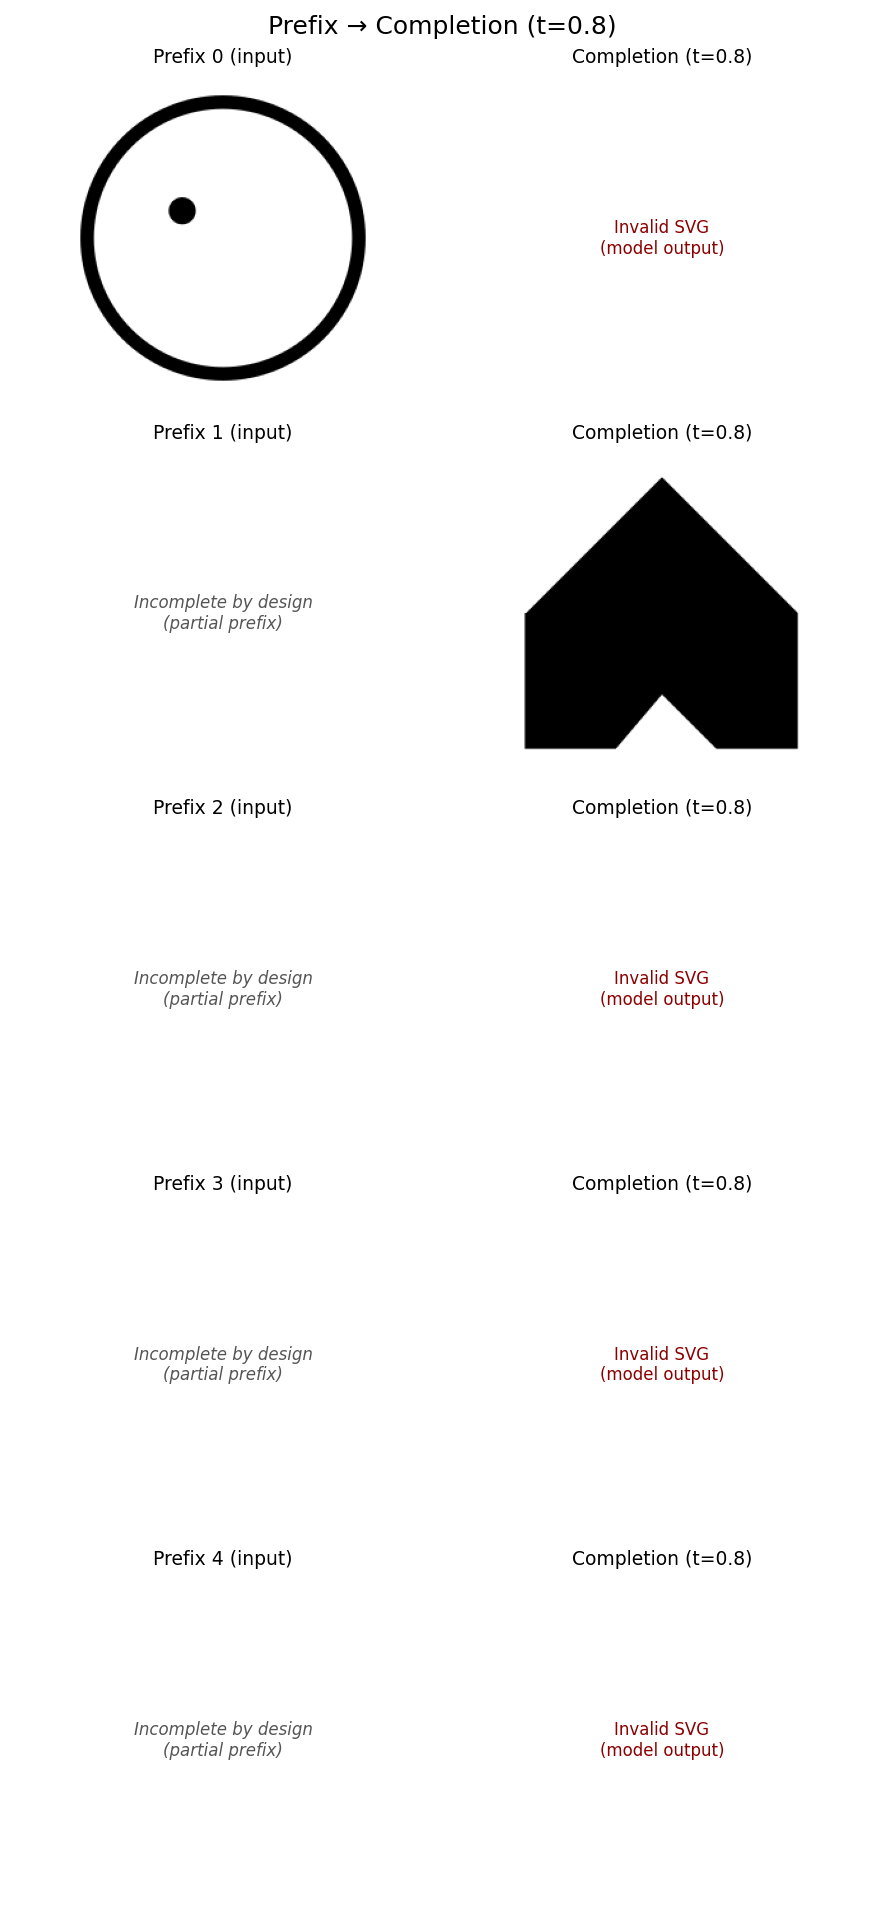

samples_temperature_comparison.png


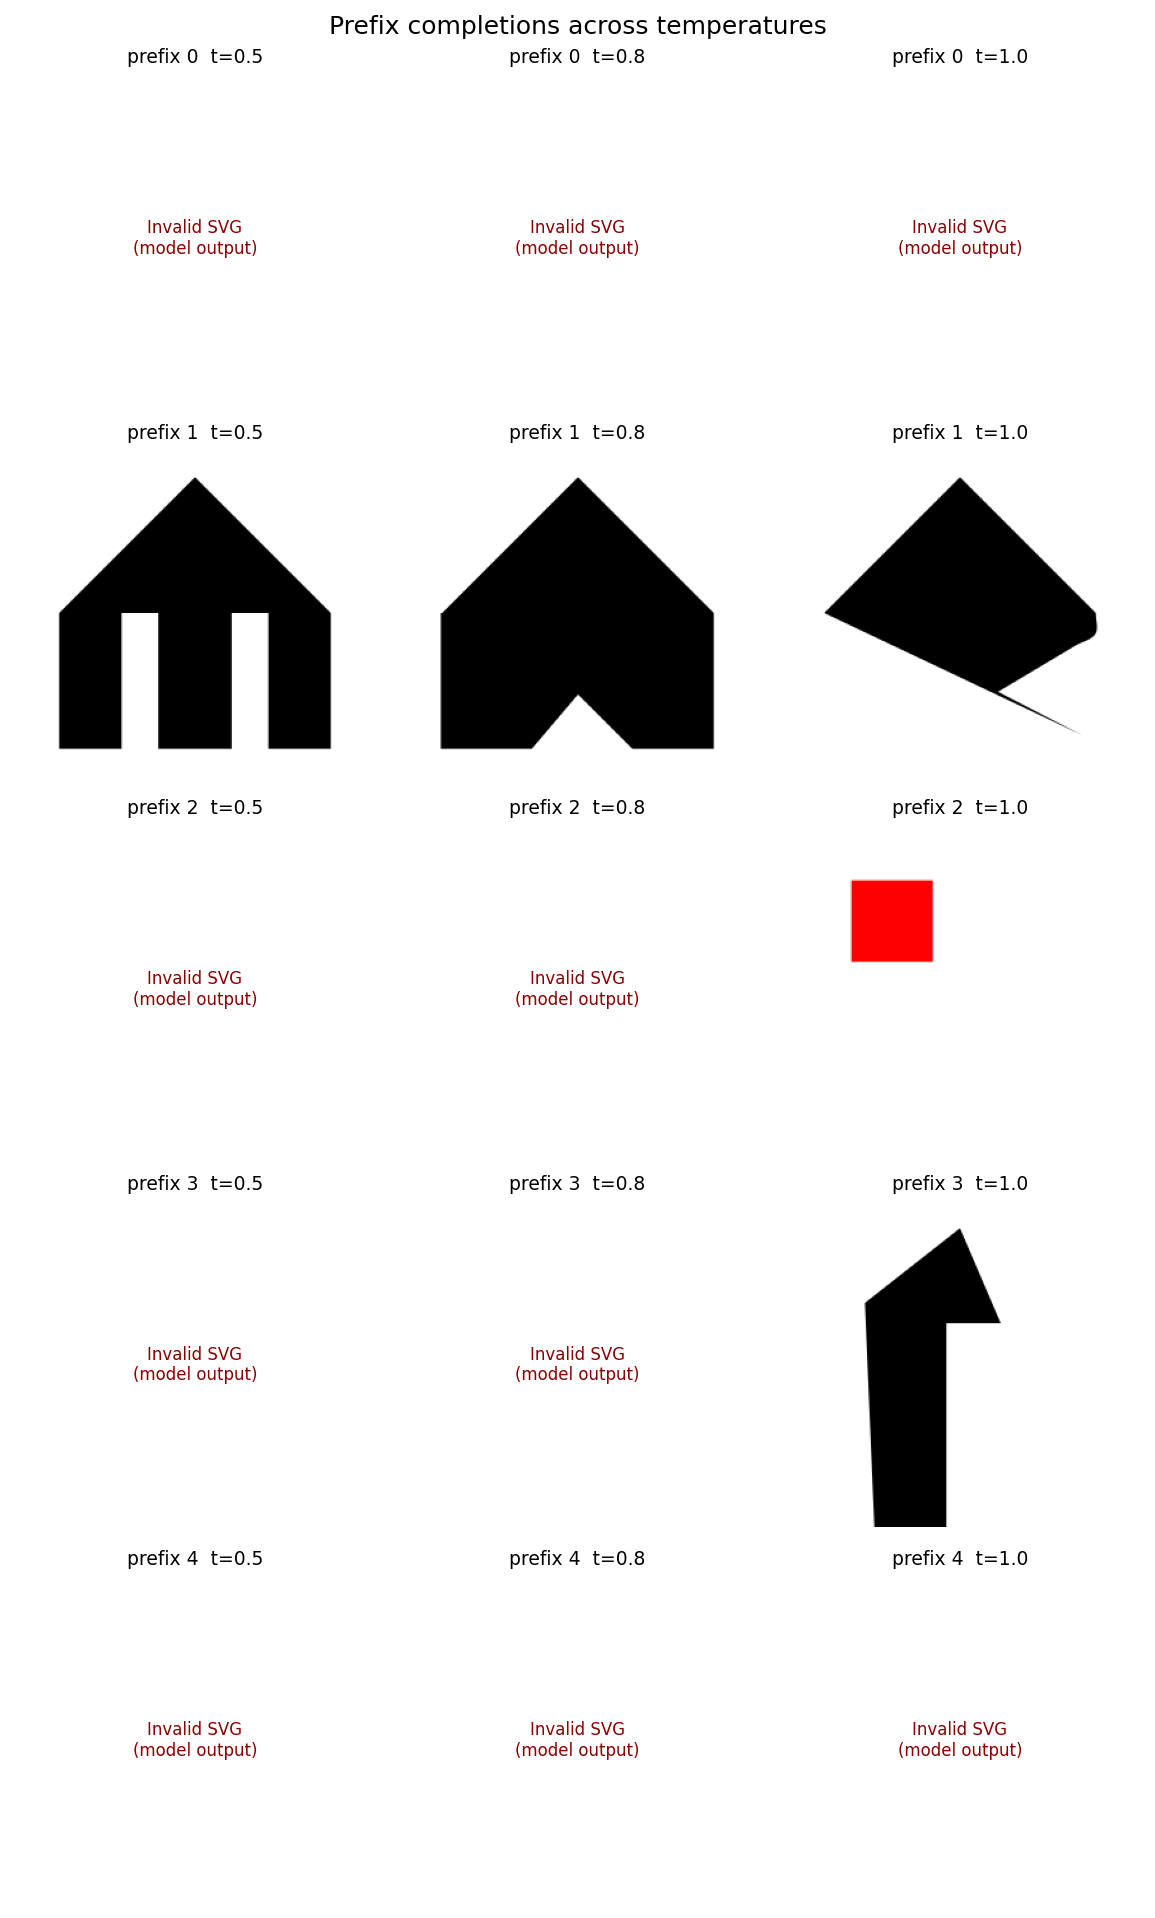

samples_unconditional_grid.png


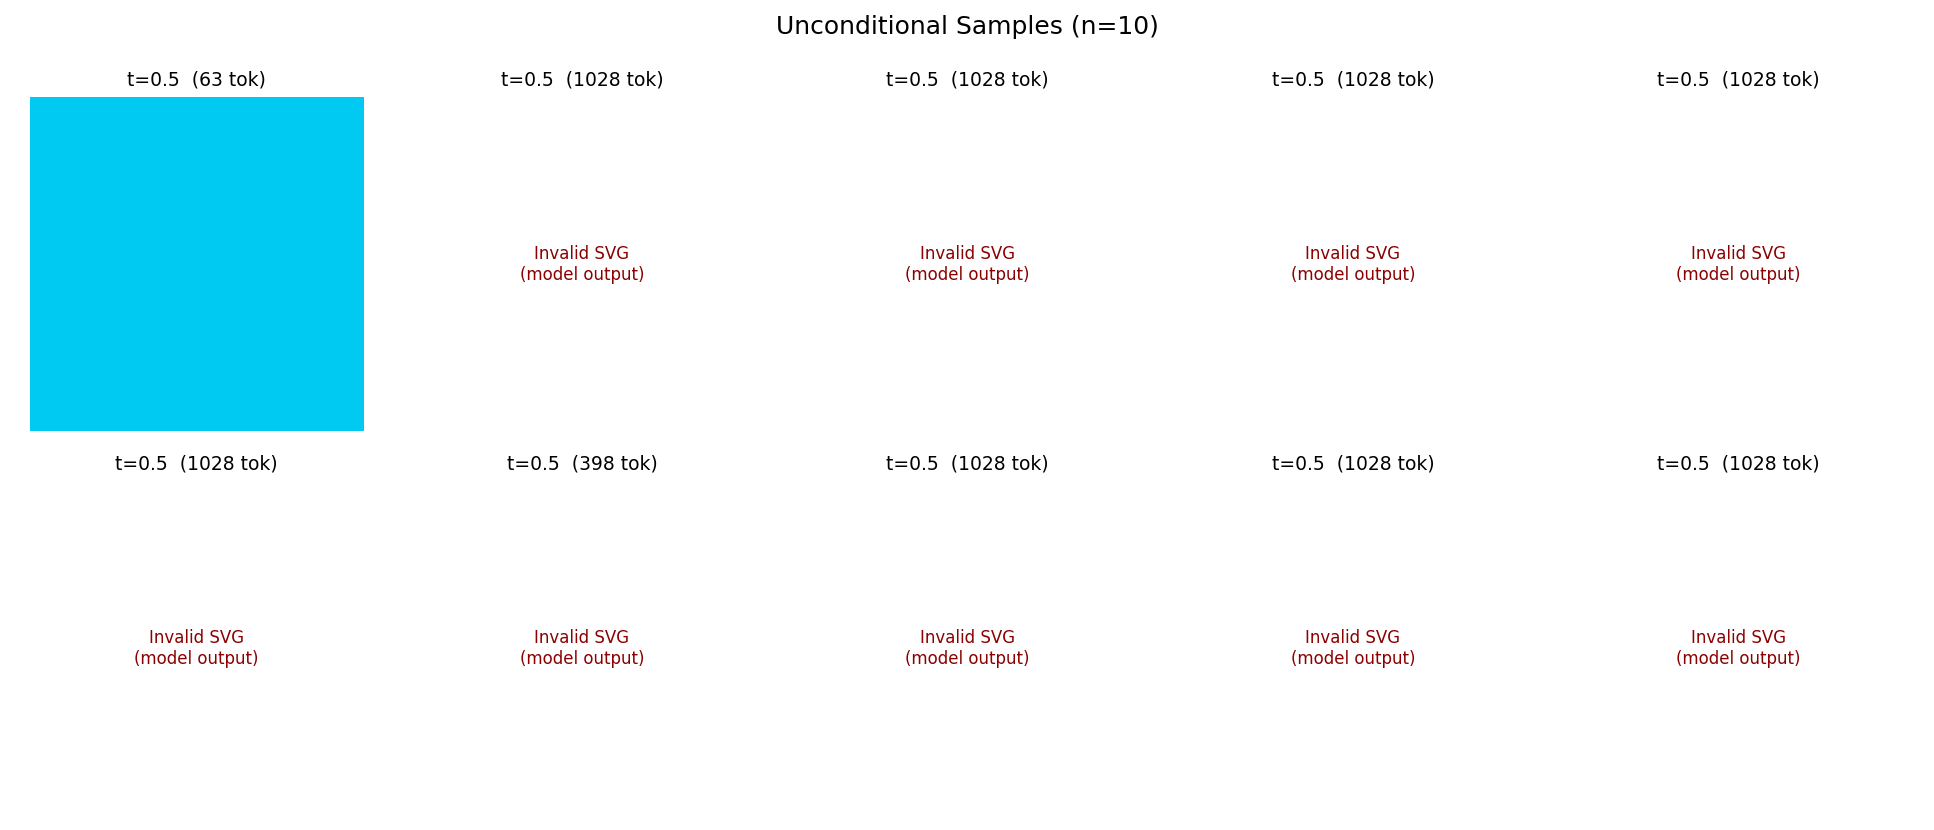

In [ ]:
from IPython.display import Image, display
import pathlib

for png in sorted(pathlib.Path('outputs/plots/balanced').glob('*.png')):
    print(png.name)
    display(Image(str(png)))